C:\Users\erojas\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\erojas\AppData\Local\Temp\ipykernel_8584\3160145248.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(logistic_model, X, ydata)


beta_0 = 1.0 beta_1 = 1.0


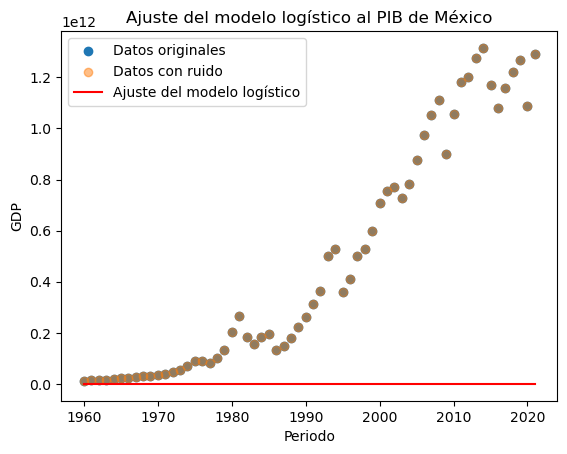

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10
5,1965,2.184000e+10
6,1966,2.432000e+10
7,1967,2.656000e+10
8,1968,2.936000e+10


In [127]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os 
from scipy.optimize import curve_fit

#importamos base de datos
os.chdir("C:/Users/erojas/Downloads")
df = pd.read_excel("Mexico GDP.xlsx")

# define X y Y 
X = df['Periodo']
Y = df['GDP']
y_noise = 20 * np.random.normal(0,1,size=X.size)
ydata = Y + y_noise

# Define el modelo logistico para proceder a las estimaciones de beta 1 y beta2
def logistic_model(X, beta1, beta2):
    Y_hat = 1 / (1 + np.exp(beta1 * (X - beta2)))
    return Y_hat

from scipy.optimize import curve_fit
popt, pcov = curve_fit(logistic_model, X, ydata)
print('beta_0 =', popt[0], 'beta_1 =', popt[1])

#Visualizacion del modelo
plt.scatter(X, Y, label='Datos originales')
plt.scatter(X, ydata, label='Datos con ruido', alpha=0.5)
plt.plot(X, logistic_model(X, *popt), color='red', label='Ajuste del modelo logístico')


plt.xlabel('Periodo')
plt.ylabel('GDP')
plt.legend()
plt.title('Ajuste del modelo logístico al PIB de México')
plt.show()
df.head(9)

In [129]:
# Normalizacion de las dos columnas
Y_normalized = Y / max(Y)

X_normalized = (X - X.min()) / (X.max() - X.min())

# aplicar curvefit para estimar valor de beta
from scipy.optimize import curve_fit
popt, pcov = curve_fit(logistic_model, X_normalized, Y_normalized)
#imprimir valores de beta 
print('beta_0 =', popt[0], 'beta_1 =', popt[1])

beta_0 = -8.197667323945664 beta_1 = 0.6452947353138625


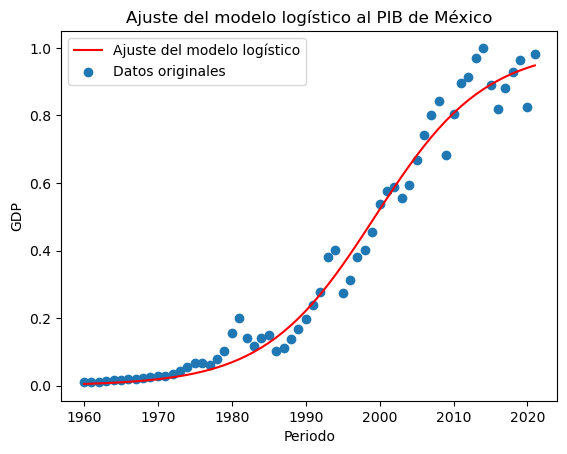

In [131]:
#Visualizacion del modelo
plt.plot(X, logistic_model(X_normalized, *popt), color='red', label='Ajuste del modelo logístico')
plt.scatter(X, Y_normalized, label='Datos originales')
plt.xlabel('Periodo')
plt.ylabel('GDP')
plt.legend()
plt.title('Ajuste del modelo logístico al PIB de México')
plt.show()

In [139]:
# Creamos la mascara para crear las bases de datos de prueba y entrenamiento
msk = np.random.rand(len(X_normalized)) <= 0.8
msk

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True, False,  True, False, False,  True, False,  True, False,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True, False,  True, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True, False,  True,  True, False, False])

In [141]:
train_x = X_normalized[msk]
test_x = X_normalized[~msk]
train_y = Y_normalized[msk]
test_y = Y_normalized[~msk]

In [143]:
popt, pcov = curve_fit(logistic_model, train_x, train_y)

In [147]:
print("beta_0 = ", popt[0], "beta_1 = ", popt[1])

beta_0 =  -8.63767271131422 beta_1 =  0.6419256556240983


In [151]:
# Prediccion
y_hat = logistic_model(test_x, *popt)

In [153]:
# Evaluacion de errores
print('Mean absolute error: %.2f' % np.mean(np.absolute(y_hat - test_y)))
print('Residual sum of squares (MSF) : %.2f' % np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print('R2-score: %.2f' % r2_score(y_hat, test_y) )

Mean absolute error: 0.04
Residual sum of squares (MSF) : 0.00
R2-score: 0.98


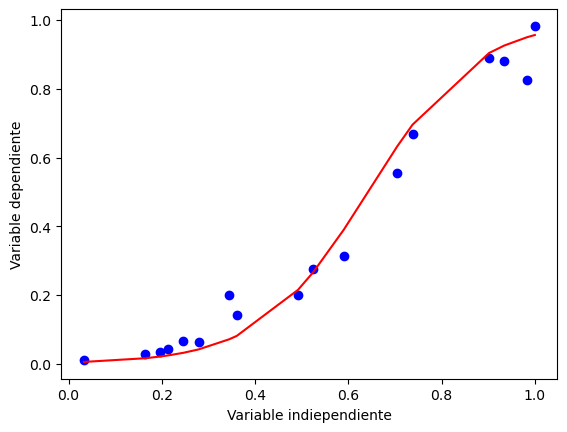

In [155]:
plt.plot(test_x, test_y, 'bo')
plt.plot(test_x, y_hat, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable indiependiente')
plt.show()

In [157]:
y_hat

2     0.005161
10    0.015848
12    0.020928
13    0.024035
15    0.031654
17    0.041586
21    0.071020
22    0.080949
30    0.214720
32    0.266294
36    0.390050
43    0.632767
45    0.695786
55    0.904073
57    0.925980
60    0.950326
61    0.956600
Name: Periodo, dtype: float64

In [159]:
test_y

2     0.011556
10    0.027004
12    0.034363
13    0.042027
15    0.066902
17    0.062199
21    0.200676
22    0.140350
30    0.198619
32    0.276092
36    0.312446
43    0.554480
45    0.667104
55    0.890916
57    0.881067
60    0.826485
61    0.983036
Name: GDP, dtype: float64

In [169]:
# Predicion del año 2022 con el modelo logistico actual y los valores de beta_0 y beta_1 calculculados mediante el curvefit 
GDP_2022_normalized = logistic_model(2022, popt[0], popt[1])
# como la informacion se normalizo para ser ajustado al modelo invertimos el proceso para obtener el valor real del PIB
GDP_2022 = GDP_2022_normalized * max(Y)
print(f"Prediccion PIB para Mexico en 2022: {GDP_2022}")

Prediccion PIB para Mexico en 2022: 1315351183524.544
